## 1. IMPORTS Y CONFIGURACIÓN

In [34]:
import pandas as pd
import numpy as np
import joblib
import os
import random

# Semilla (mismo NIA que en el notebook anterior)
SEMILLA = 100522258
np.random.seed(SEMILLA)
random.seed(SEMILLA)

# Últimos dos dígitos del NIA para el nombre del archivo
XX = 13 

print(f"Semilla fijada: {SEMILLA}")
print(f"Sufijo del archivo: {XX}")

Semilla fijada: 100522258
Sufijo del archivo: 13


## 2. CARGAR MODELO FINAL

In [35]:
# Verificar que el modelo existe
model_path = '../models/modelo_final.joblib'

if not os.path.exists(model_path):
    raise FileNotFoundError(f"No se encuentra {model_path}. Ejecuta primero 01_eda_y_modelos.ipynb")

# Introducimos la funcion transformer aquí porque si no no importa bien el modelo
# Se podría hacer de forma más limpia y ordenada con un odulo de python aparte, pero sólo se pueden enviar los notebook
def crear_nunca_contactado_eliminar_pdays(df):
    df_copy = df.copy()
    df_copy["nunca_contactado"] = (df_copy['pdays'] == -1).astype(int)
    df_copy = df_copy.drop('pdays', axis=1)
    return df_copy
# Cargar modelo
model = joblib.load(model_path)
print("Modelo cargado correctamente")
print(f"Tipo de modelo: {type(model.named_steps[list(model.named_steps.keys())[-1]]).__name__}")

Modelo cargado correctamente
Tipo de modelo: SVC


## 3. CARGAR DATOS DE COMPETICIÓN

In [36]:
# Ruta del archivo de competición
competition_path = f'../data/bank_competition_{XX}.pkl'

if not os.path.exists(competition_path):
    raise FileNotFoundError(f"No se encuentra {competition_path}")

# Cargar datos
df_competition = pd.read_pickle(competition_path)
print(f"Datos cargados: {df_competition.shape}")
print(f"Columnas: {df_competition.columns.tolist()}")
print(f"\nPrimeras 5 filas:")
df_competition.head()

Datos cargados: (162, 16)
Columnas: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

Primeras 5 filas:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
5553,43,management,married,tertiary,no,78,yes,no,cellular,21,nov,36,1,109,1,other
915,34,housemaid,married,secondary,no,0,yes,no,unknown,30,oct,154,1,-1,0,unknown
7652,54,technician,married,secondary,no,3323,yes,yes,cellular,8,apr,59,3,-1,0,unknown
5065,43,blue-collar,single,primary,no,-399,no,yes,cellular,28,jul,662,3,-1,0,unknown
3338,35,blue-collar,married,secondary,no,262,no,no,cellular,15,mar,427,1,181,3,success


## 4. VERIFICAR PREPROCESAMIENTO

**Nota:** La pipeline del modelo ya incluye la transformación de `pdays` (crear `pdays_never` y eliminar `pdays`).  
No necesitamos hacer nada manualmente, el modelo lo aplica automáticamente al predecir.

In [37]:
# Verificamos que la pipeline tiene el transformador de pdays
print("Pasos de la pipeline:")
for name, step in model.named_steps.items():
    print(f"  - {name}: {type(step).__name__}")

# Comprobar si la pipeline incluye la transformación de pdays
has_pdays_transform = any('pdays' in str(step) or 'transform' in str(step) for step in model.named_steps.values())
print(f"\n¿La pipeline incluye transformación de pdays? {'Sí' if has_pdays_transform else '⚠️ No'}")

Pasos de la pipeline:
  - pdays: FunctionTransformer
  - preprocessor: ColumnTransformer
  - svm: SVC

¿La pipeline incluye transformación de pdays? Sí


## 5. GENERAR PREDICCIONES

In [38]:
# Predicciones de clase
predicciones = model.predict(df_competition)

# Probabilidades (para clase 'yes')
probabilidades = model.predict_proba(df_competition)[:, 1]

print(f"Predicciones generadas: {len(predicciones)}")
print(f"\nDistribución de predicciones:")
print(f"  - 'yes': {(predicciones == 1).sum()} ({(predicciones == 1).sum()/len(predicciones)*100:.1f}%)")
print(f"  - 'no': {(predicciones == 0).sum()} ({(predicciones == 0).sum()/len(predicciones)*100:.1f}%)")

# Estadísticas de probabilidades
print(f"\nEstadísticas de probabilidades para clase 'yes':")
print(f"  - Media: {probabilidades.mean():.4f}")
print(f"  - Mediana: {np.median(probabilidades):.4f}")
print(f"  - Desviación estándar: {probabilidades.std():.4f}")
print(f"  - Mínimo: {probabilidades.min():.4f}")
print(f"  - Máximo: {probabilidades.max():.4f}")

Predicciones generadas: 162

Distribución de predicciones:
  - 'yes': 69 (42.6%)
  - 'no': 93 (57.4%)

Estadísticas de probabilidades para clase 'yes':
  - Media: 0.4197
  - Mediana: 0.3403
  - Desviación estándar: 0.3567
  - Mínimo: 0.0012
  - Máximo: 0.9958


## 6. VISUALIZACIÓN DE RESULTADOS

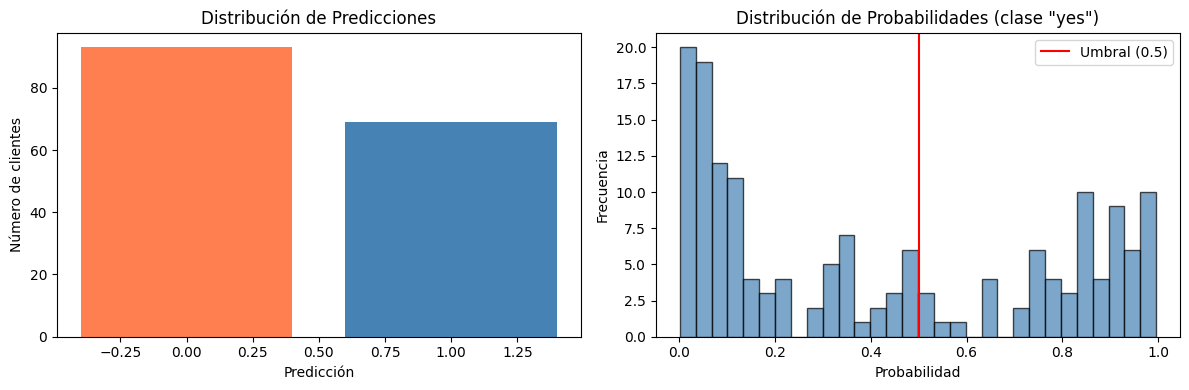

In [39]:
import matplotlib.pyplot as plt

# Distribución de predicciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras de predicciones
pred_counts = pd.Series(predicciones).value_counts()
axes[0].bar(pred_counts.index, pred_counts.values, color=['coral', 'steelblue'])
axes[0].set_title('Distribución de Predicciones')
axes[0].set_ylabel('Número de clientes')
axes[0].set_xlabel('Predicción')

# Histograma de probabilidades
axes[1].hist(probabilidades, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0.5, color='red', linestyle='-', label='Umbral (0.5)')
axes[1].set_title('Distribución de Probabilidades (clase "yes")')
axes[1].set_xlabel('Probabilidad')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. GUARDAR PREDICCIONES

In [40]:
# Crear directorio si no existe
os.makedirs('../outputs', exist_ok=True)

# Crear DataFrame con predicciones
pred_df = pd.DataFrame({
    'prediction': predicciones,
    'probability_yes': probabilidades
})

# Guardar a CSV
output_path = '../outputs/predicciones.csv'
pred_df.to_csv(output_path, index=False)

print(f"Predicciones guardadas en: {output_path}")
print(f"\nPrimeras 10 predicciones:")
print(pred_df.head(10))

Predicciones guardadas en: ../outputs/predicciones.csv

Primeras 10 predicciones:
   prediction  probability_yes
0           0         0.043505
1           1         0.469559
2           0         0.074905
3           1         0.548864
4           1         0.995816
5           0         0.042787
6           1         0.967443
7           0         0.097036
8           1         0.980235
9           0         0.137419


## 8. VERIFICACIÓN DE REPRODUCIBILIDAD

Para garantizar que las predicciones son reproducibles, guardamos también la versión del modelo y la semilla utilizada.

In [41]:
# Guardar metadatos
metadata = {
    'semilla': SEMILLA,
    'modelo': str(type(model.named_steps[list(model.named_steps.keys())[-1]]).__name__),
    'num_predicciones': len(predicciones),
    'distribucion_yes': float((predicciones == 1).sum() / len(predicciones)),
    'distribucion_no': float((predicciones == 0).sum() / len(predicciones))
}

metadata_df = pd.DataFrame([metadata])
metadata_df.to_csv('../outputs/predicciones_metadata.csv', index=False)
print("Metadatos guardados en '../outputs/predicciones_metadata.csv'")
print(f"\nMetadatos:")
print(metadata_df.to_string(index=False))

Metadatos guardados en '../outputs/predicciones_metadata.csv'

Metadatos:
  semilla modelo  num_predicciones  distribucion_yes  distribucion_no
100522258    SVC               162          0.425926         0.574074


## 9. RESUMEN FINAL

In [42]:
print("RESUMEN DE PREDICCIONES PARA COMPETICIÓN")
print(f"Archivo de entrada: bank_competition_{XX}.pkl")
print(f"Número de clientes: {len(df_competition)}")
print(f"Número de predicciones: {len(predicciones)}")
print(f"Predicciones 'yes': {(predicciones == 'yes').sum()} ({100*(predicciones=='yes').sum()/len(predicciones):.1f}%)")
print(f"Predicciones 'no': {(predicciones == 'no').sum()} ({100*(predicciones=='no').sum()/len(predicciones):.1f}%)")
print(f"Probabilidad media de 'yes': {probabilidades.mean():.4f}")
print("\n")
print("\nNotebook completado. Archivos generados:")
print("   - ../outputs/predicciones.csv")
print("   - ../outputs/predicciones_metadata.csv")
print("   - ../outputs/predicciones_distribucion.png")

RESUMEN DE PREDICCIONES PARA COMPETICIÓN
Archivo de entrada: bank_competition_13.pkl
Número de clientes: 162
Número de predicciones: 162
Predicciones 'yes': 0 (0.0%)
Predicciones 'no': 0 (0.0%)
Probabilidad media de 'yes': 0.4197



Notebook completado. Archivos generados:
   - ../outputs/predicciones.csv
   - ../outputs/predicciones_metadata.csv
   - ../outputs/predicciones_distribucion.png
